# M5 Data Catalog and Quality Assessment

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ericmavigo/retail-demand-forecasting/blob/main/notebooks/00_DATA_CATALOG_AND_QUALITY.ipynb)

**Purpose:** inspect every official competition file before modeling. This notebook explains what each table contains, profiles missing values and duplicates, validates table relationships, measures price coverage and identifies data-quality risks.

> **Public portfolio snapshot:** the outputs below were generated from the official Kaggle M5 competition files. A private Kaggle token is required only to rerun the download; no credential is stored in this repository.

## 1. Environment

Run the notebook from top to bottom. In Google Colab, this cell installs the small set of required packages.

In [1]:
from pathlib import Path
import sys
import subprocess

if 'google.colab' in sys.modules:
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '-q',
        'kagglehub>=1.0,<2', 'pandas>=2.2,<3', 'numpy>=2,<3', 'matplotlib>=3.9,<4',
    ])

import numpy as np
import pandas as pd
get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_seq_items', None)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
plt.style.use('seaborn-v0_8-whitegrid')

COLORS = {
    'navy': '#17324D', 'blue': '#2F80ED', 'teal': '#16A085',
    'orange': '#F2994A', 'red': '#EB5757', 'gray': '#667085',
}

## 2. Authenticate and download the official files

1. Accept the [M5 competition rules](https://www.kaggle.com/competitions/m5-forecasting-accuracy/rules).
2. Create an API token in [Kaggle Settings](https://www.kaggle.com/settings/api).
3. In Colab, save it in **Secrets** as `KAGGLE_API_TOKEN` and enable notebook access.

If the secret is unavailable, `kagglehub.login()` opens an interactive login form. Never paste a token into a public code cell.

In [2]:
import kagglehub

try:
    path = kagglehub.competition_download('m5-forecasting-accuracy')
except Exception as error:
    if error.__class__.__name__ != 'UnauthenticatedError':
        raise
    print('Kaggle authentication is required. Paste your private API token in the login form.')
    kagglehub.login()
    path = kagglehub.competition_download('m5-forecasting-accuracy')

DATA_DIR = Path(path)
if not (DATA_DIR / 'calendar.csv').exists():
    DATA_DIR = next(candidate.parent for candidate in DATA_DIR.rglob('calendar.csv'))

required_files = {
    'calendar.csv', 'sell_prices.csv', 'sales_train_validation.csv',
    'sales_train_evaluation.csv', 'sample_submission.csv',
}
available_files = {candidate.name for candidate in DATA_DIR.glob('*.csv')}
assert required_files.issubset(available_files), f'Missing files: {sorted(required_files - available_files)}'
print('Official M5 files available:', len(required_files))

Execution source: official Kaggle M5 competition files
Official M5 files available: 5


## 3. Load every source table

All five official CSV files are loaded. The validation and evaluation sales tables are wide matrices: one row per product-store series and one column per historical day.

In [3]:
file_roles = {
    'calendar': 'Dates, retail weeks, events and SNAP program flags',
    'sell_prices': 'Weekly selling price by store and product',
    'sales_train_validation': 'Daily unit sales through d_1913',
    'sales_train_evaluation': 'Daily unit sales through d_1941',
    'sample_submission': 'Required 28-day forecast submission structure',
}

tables = {
    name: pd.read_csv(DATA_DIR / f'{name}.csv', parse_dates=['date'] if name == 'calendar' else None)
    for name in file_roles
}

calendar = tables['calendar']
prices = tables['sell_prices']
sales_validation = tables['sales_train_validation']
sales_evaluation = tables['sales_train_evaluation']
submission = tables['sample_submission']

catalog = pd.DataFrame([
    {
        'table': name,
        'rows': len(table),
        'columns': table.shape[1],
        'memory_mb': table.memory_usage(deep=True).sum() / 1024**2,
        'role': file_roles[name],
    }
    for name, table in tables.items()
]).sort_values('memory_mb', ascending=False)

display(catalog.style.format({'rows': '{:,.0f}', 'columns': '{:,.0f}', 'memory_mb': '{:,.1f} MB'}))

,table,rows,columns,memory_mb,role
3,sales_train_evaluation,"30,490","1,947",454.7 MB,Daily unit sales through d_1941
2,sales_train_validation,"30,490","1,919",448.2 MB,Daily unit sales through d_1913
1,sell_prices,"6,841,121",4,318.1 MB,Weekly selling price by store and product
4,sample_submission,"60,980",29,15.2 MB,Required 28-day forecast submission structure
0,calendar,"1,969",14,0.2 MB,"Dates, retail weeks, events and SNAP program flags"


## 4. Raw table discovery — before making assumptions

At this point we do not yet decide what the project should analyze. We inspect each file exactly as received and ask basic questions:

- What does a row look like?
- How many rows and columns exist?
- What are all the column names?
- Which data type does every column use?
- How many non-null values and how much memory does the table contain?
- What ranges, averages, frequencies and common values appear?

The same discovery commands are executed for every official table. Wide outputs are transposed when necessary so every column remains readable vertically.

### 4.1 `calendar.csv`

**Initial description from the competition file name:** Dates, retail weeks, events and state SNAP flags. The commands below verify what is actually present.

In [4]:
calendar.head(10)

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1
5,2011-02-03,11101,Thursday,6,2,2011,d_6,NaN,NaN,NaN,NaN,1,1,1
6,2011-02-04,11101,Friday,7,2,2011,d_7,NaN,NaN,NaN,NaN,1,0,0
7,2011-02-05,11102,Saturday,1,2,2011,d_8,NaN,NaN,NaN,NaN,1,1,1
8,2011-02-06,11102,Sunday,2,2,2011,d_9,SuperBowl,Sporting,NaN,NaN,1,1,1
9,2011-02-07,11102,Monday,3,2,2011,d_10,NaN,NaN,NaN,NaN,1,1,0


In [5]:
calendar.shape

(1969, 14)

In [6]:
# df.columns — list every column name without truncating the sequence.
calendar.columns

Index(['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd',
       'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
       'snap_CA', 'snap_TX', 'snap_WI'],
      dtype='str')

In [7]:
# df.dtypes — show the data type of every column.
with pd.option_context('display.max_rows', None):
    display(calendar.dtypes.rename('dtype').to_frame())

,dtype
date,datetime64[us]
wm_yr_wk,int64
weekday,str
wday,int64
month,int64
year,int64
d,str
event_name_1,str
event_type_1,str
event_name_2,str


In [8]:
# df.info() — non-null counts, dtypes and memory usage.
calendar.info()

<class 'pandas.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1969 non-null   datetime64[us]
 1   wm_yr_wk      1969 non-null   int64         
 2   weekday       1969 non-null   str           
 3   wday          1969 non-null   int64         
 4   month         1969 non-null   int64         
 5   year          1969 non-null   int64         
 6   d             1969 non-null   str           
 7   event_name_1  162 non-null    str           
 8   event_type_1  162 non-null    str           
 9   event_name_2  5 non-null      str           
 10  event_type_2  5 non-null      str           
 11  snap_CA       1969 non-null   int64         
 12  snap_TX       1969 non-null   int64         
 13  snap_WI       1969 non-null   int64         
dtypes: datetime64[us](1), int64(7), str(6)
memory usage: 243.9 KB


In [9]:
# df.describe() — descriptive statistics for numeric columns.
with pd.option_context('display.max_rows', None):
    display(calendar.describe().T)

,count,mean,min,25%,50%,75%,max,std
date,1969,2013-10-09 00:00:00,2011-01-29 00:00:00,2012-06-04 00:00:00,2013-10-09 00:00:00,2015-02-13 00:00:00,2016-06-19 00:00:00,NaN
wm_yr_wk,"1,969.00","11,347.09","11,101.00","11,219.00","11,337.00","11,502.00","11,621.00",155.28
wday,"1,969.00",4.00,1.00,2.00,4.00,6.00,7.00,2.00
month,"1,969.00",6.33,1.00,3.00,6.00,9.00,12.00,3.42
year,"1,969.00","2,013.29","2,011.00","2,012.00","2,013.00","2,015.00","2,016.00",1.58
snap_CA,"1,969.00",0.33,0.00,0.00,0.00,1.00,1.00,0.47
snap_TX,"1,969.00",0.33,0.00,0.00,0.00,1.00,1.00,0.47
snap_WI,"1,969.00",0.33,0.00,0.00,0.00,1.00,1.00,0.47


In [10]:
# df.describe(include='all') — numeric and categorical statistics.
with pd.option_context('display.max_rows', None):
    display(calendar.describe(include='all').T)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,1969,NaN,NaN,NaN,2013-10-09 00:00:00,2011-01-29 00:00:00,2012-06-04 00:00:00,2013-10-09 00:00:00,2015-02-13 00:00:00,2016-06-19 00:00:00,NaN
wm_yr_wk,"1,969.00",NaN,NaN,NaN,"11,347.09","11,101.00","11,219.00","11,337.00","11,502.00","11,621.00",155.28
weekday,1969,7,Saturday,282,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wday,"1,969.00",NaN,NaN,NaN,4.00,1.00,2.00,4.00,6.00,7.00,2.00
month,"1,969.00",NaN,NaN,NaN,6.33,1.00,3.00,6.00,9.00,12.00,3.42
year,"1,969.00",NaN,NaN,NaN,"2,013.29","2,011.00","2,012.00","2,013.00","2,015.00","2,016.00",1.58
d,1969,1969,d_1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_name_1,162,30,SuperBowl,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_type_1,162,4,Religious,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_name_2,5,4,Father's day,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 4.2 `sell_prices.csv`

**Initial description from the competition file name:** Weekly price by store and product. The commands below verify what is actually present.

In [11]:
prices.head(10)

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26
5,CA_1,HOBBIES_1_001,11330,8.26
6,CA_1,HOBBIES_1_001,11331,8.26
7,CA_1,HOBBIES_1_001,11332,8.26
8,CA_1,HOBBIES_1_001,11333,8.26
9,CA_1,HOBBIES_1_001,11334,8.26


In [12]:
prices.shape

(6841121, 4)

In [13]:
# df.columns — list every column name without truncating the sequence.
prices.columns

Index(['store_id', 'item_id', 'wm_yr_wk', 'sell_price'], dtype='str')

In [14]:
# df.dtypes — show the data type of every column.
with pd.option_context('display.max_rows', None):
    display(prices.dtypes.rename('dtype').to_frame())

,dtype
store_id,str
item_id,str
wm_yr_wk,int64
sell_price,float64


In [15]:
# df.info() — non-null counts, dtypes and memory usage.
prices.info()

<class 'pandas.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    str    
 1   item_id     str    
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 318.1 MB


In [16]:
# df.describe() — descriptive statistics for numeric columns.
with pd.option_context('display.max_rows', None):
    display(prices.describe().T)

,count,mean,std,min,25%,50%,75%,max
wm_yr_wk,"6,841,121.00","11,382.94",148.61,"11,101.00","11,247.00","11,411.00","11,517.00","11,621.00"
sell_price,"6,841,121.00",4.41,3.41,0.01,2.18,3.47,5.84,107.32


In [17]:
# df.describe(include='all') — numeric and categorical statistics.
with pd.option_context('display.max_rows', None):
    display(prices.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
store_id,6841121,10,TX_2,701214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_id,6841121,3049,HOBBIES_1_010,2820,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wm_yr_wk,"6,841,121.00",NaN,NaN,NaN,"11,382.94",148.61,"11,101.00","11,247.00","11,411.00","11,517.00","11,621.00"
sell_price,"6,841,121.00",NaN,NaN,NaN,4.41,3.41,0.01,2.18,3.47,5.84,107.32


### 4.3 `sales_train_validation.csv`

**Initial description from the competition file name:** Product-store sales through day 1,913. The commands below verify what is actually present.

In [18]:
sales_validation.head(10)

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,...,d_1884,d_1885,d_1886,d_1887,d_1888,d_1889,d_1890,d_1891,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,1,1,0,0,0,0,0,1,0,4,2,3,0,1,2,0,0,0,1,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,2,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,6,6,0,0,0,0,3,1,2,1,3,1,0,2,5,4,2,0,3,0,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,4,4,0,1,4,0,1,0,1,0,1,1,2,0,1,1,2,1,1,0,1,1,2,2,2,4
5,HOBBIES_1_006_CA_1_validation,HOBBIES_1_006,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,2,0,1,3,0,0,0,0,0,0,3,0,1,0,0,1,4,0,0,0,1,0,1,0,0,0,2,0,0
6,HOBBIES_1_007_CA_1_validation,HOBBIES_1_007,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,2,0,0,1,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,1,0,1,0,0,1,1
7,HOBBIES_1_008_CA_1_validation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,12,15,0,0,0,4,6,5,7,0,13,2,2,20,9,3,0,1,0,0,0,10,4,4,...,0,0,0,11,5,2,12,38,22,2,0,10,26,8,12,4,5,2,8,4,0,0,1,37,3,4,6,3,2,1
8,HOBBIES_1_009_CA_1_validation,HOBBIES_1_009,HOBBIES_1,HOBBIES,CA_1,CA,2,0,7,3,0,2,3,9,0,0,4,3,1,0,4,4,1,2,0,1,1,5,2,2,...,0,0,0,2,0,1,2,0,3,0,0,0,0,0,1,1,0,7,0,0,0,0,1,1,6,0,0,0,0,0
9,HOBBIES_1_010_CA_1_validation,HOBBIES_1_010,HOBBIES_1,HOBBIES,CA_1,CA,0,0,1,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,2,0,0,0,1,0,...,0,0,0,1,1,1,1,0,3,2,2,1,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,2,0,2


In [19]:
sales_validation.shape

(30490, 1919)

In [20]:
# df.columns — list every column name without truncating the sequence.
sales_validation.columns

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1',
       'd_2', 'd_3', 'd_4', 'd_5', 'd_6', 'd_7', 'd_8', 'd_9', 'd_10', 'd_11',
       'd_12', 'd_13', 'd_14', 'd_15', 'd_16', 'd_17', 'd_18', 'd_19', 'd_20',
       'd_21', 'd_22', 'd_23', 'd_24', 'd_25', 'd_26', 'd_27', 'd_28', 'd_29',
       'd_30', 'd_31', 'd_32', 'd_33', 'd_34', 'd_35', 'd_36', 'd_37', 'd_38',
       'd_39', 'd_40', 'd_41', 'd_42', 'd_43', 'd_44', 'd_45', 'd_46', 'd_47',
       'd_48', 'd_49', 'd_50', 'd_51', 'd_52', 'd_53', 'd_54', 'd_55', 'd_56',
       'd_57', 'd_58', 'd_59', 'd_60', 'd_61', 'd_62', 'd_63', 'd_64', 'd_65',
       'd_66', 'd_67', 'd_68', 'd_69', 'd_70', 'd_71', 'd_72', 'd_73', 'd_74',
       'd_75', 'd_76', 'd_77', 'd_78', 'd_79', 'd_80', 'd_81', 'd_82', 'd_83',
       'd_84', 'd_85', 'd_86', 'd_87', 'd_88', 'd_89', 'd_90', 'd_91', 'd_92',
       'd_93', 'd_94', 'd_95', 'd_96', 'd_97', 'd_98', 'd_99', 'd_100',
       'd_101', 'd_102', 'd_103', 'd_104', 'd_105', 'd_106', '

In [21]:
# df.dtypes — show the data type of every column.
with pd.option_context('display.max_rows', None):
    display(sales_validation.dtypes.rename('dtype').to_frame())

,dtype
id,str
item_id,str
dept_id,str
cat_id,str
store_id,str
state_id,str
d_1,int64
d_2,int64
d_3,int64
d_4,int64


In [22]:
# df.info() — non-null counts, dtypes and memory usage.
sales_validation.info()

<class 'pandas.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), str(6)
memory usage: 448.2 MB


In [23]:
# df.describe() — descriptive statistics for numeric columns.
with pd.option_context('display.max_rows', None):
    display(sales_validation.describe().T)

,count,mean,std,min,25%,50%,75%,max
d_1,"30,490.00",1.07,5.13,0.00,0.00,0.00,0.00,360.00
d_2,"30,490.00",1.04,5.37,0.00,0.00,0.00,0.00,436.00
d_3,"30,490.00",0.78,3.67,0.00,0.00,0.00,0.00,207.00
d_4,"30,490.00",0.83,4.42,0.00,0.00,0.00,0.00,323.00
d_5,"30,490.00",0.63,3.38,0.00,0.00,0.00,0.00,296.00
d_6,"30,490.00",0.96,4.79,0.00,0.00,0.00,0.00,314.00
d_7,"30,490.00",0.92,5.06,0.00,0.00,0.00,0.00,316.00
d_8,"30,490.00",1.24,6.62,0.00,0.00,0.00,0.00,370.00
d_9,"30,490.00",1.07,5.92,0.00,0.00,0.00,0.00,385.00
d_10,"30,490.00",0.84,4.21,0.00,0.00,0.00,0.00,353.00


In [24]:
# df.describe(include='all') — numeric and categorical statistics.
with pd.option_context('display.max_rows', None):
    display(sales_validation.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,30490,30490,HOBBIES_1_001_CA_1_validation,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_id,30490,3049,HOBBIES_1_001,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dept_id,30490,7,FOODS_3,8230,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cat_id,30490,3,FOODS,14370,NaN,NaN,NaN,NaN,NaN,NaN,NaN
store_id,30490,10,CA_1,3049,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state_id,30490,3,CA,12196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
d_1,"30,490.00",NaN,NaN,NaN,1.07,5.13,0.00,0.00,0.00,0.00,360.00
d_2,"30,490.00",NaN,NaN,NaN,1.04,5.37,0.00,0.00,0.00,0.00,436.00
d_3,"30,490.00",NaN,NaN,NaN,0.78,3.67,0.00,0.00,0.00,0.00,207.00
d_4,"30,490.00",NaN,NaN,NaN,0.83,4.42,0.00,0.00,0.00,0.00,323.00


### 4.4 `sales_train_evaluation.csv`

**Initial description from the competition file name:** Product-store sales through day 1,941. The commands below verify what is actually present.

In [25]:
sales_evaluation.head(10)

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,...,d_1912,d_1913,d_1914,d_1915,d_1916,d_1917,d_1918,d_1919,d_1920,d_1921,d_1922,d_1923,d_1924,d_1925,d_1926,d_1927,d_1928,d_1929,d_1930,d_1931,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,0,2,0,3,5,0,0,1,1,0,2,1,2,2,1,0,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,1,1,0,2,1,0,0,0,0,2,1,3,0,0,1,0,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,7,2,0,0,1,2,4,1,6,4,0,0,0,2,2,4,2,1,1,1,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,2,4,1,0,2,3,1,0,3,2,3,1,1,3,2,3,2,2,2,2,0,0,0,2,1,0,0,2,1,0
5,HOBBIES_1_006_CA_1_evaluation,HOBBIES_1_006,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,2,4,1,0,0,0,2,1,0,0,3,0,5,2,1,0,0,1,0,0,5,2,0
6,HOBBIES_1_007_CA_1_evaluation,HOBBIES_1_007,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1,1,0
7,HOBBIES_1_008_CA_1_evaluation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,12,15,0,0,0,4,6,5,7,0,13,2,2,20,9,3,0,1,0,0,0,10,4,4,...,2,1,19,3,2,8,8,23,26,9,4,8,5,8,5,0,3,1,18,47,7,0,6,0,15,5,4,1,40,32
8,HOBBIES_1_009_CA_1_evaluation,HOBBIES_1_009,HOBBIES_1,HOBBIES,CA_1,CA,2,0,7,3,0,2,3,9,0,0,4,3,1,0,4,4,1,2,0,1,1,5,2,2,...,0,0,0,2,6,0,0,0,0,0,0,0,8,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
9,HOBBIES_1_010_CA_1_evaluation,HOBBIES_1_010,HOBBIES_1,HOBBIES,CA_1,CA,0,0,1,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,2,0,0,0,1,0,...,0,2,0,2,1,0,0,0,0,0,0,0,0,2,0,2,1,0,0,1,0,0,1,0,2,1,1,0,0,1


In [26]:
sales_evaluation.shape

(30490, 1947)

In [27]:
# df.columns — list every column name without truncating the sequence.
sales_evaluation.columns

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1',
       'd_2', 'd_3', 'd_4', 'd_5', 'd_6', 'd_7', 'd_8', 'd_9', 'd_10', 'd_11',
       'd_12', 'd_13', 'd_14', 'd_15', 'd_16', 'd_17', 'd_18', 'd_19', 'd_20',
       'd_21', 'd_22', 'd_23', 'd_24', 'd_25', 'd_26', 'd_27', 'd_28', 'd_29',
       'd_30', 'd_31', 'd_32', 'd_33', 'd_34', 'd_35', 'd_36', 'd_37', 'd_38',
       'd_39', 'd_40', 'd_41', 'd_42', 'd_43', 'd_44', 'd_45', 'd_46', 'd_47',
       'd_48', 'd_49', 'd_50', 'd_51', 'd_52', 'd_53', 'd_54', 'd_55', 'd_56',
       'd_57', 'd_58', 'd_59', 'd_60', 'd_61', 'd_62', 'd_63', 'd_64', 'd_65',
       'd_66', 'd_67', 'd_68', 'd_69', 'd_70', 'd_71', 'd_72', 'd_73', 'd_74',
       'd_75', 'd_76', 'd_77', 'd_78', 'd_79', 'd_80', 'd_81', 'd_82', 'd_83',
       'd_84', 'd_85', 'd_86', 'd_87', 'd_88', 'd_89', 'd_90', 'd_91', 'd_92',
       'd_93', 'd_94', 'd_95', 'd_96', 'd_97', 'd_98', 'd_99', 'd_100',
       'd_101', 'd_102', 'd_103', 'd_104', 'd_105', 'd_106', '

In [28]:
# df.dtypes — show the data type of every column.
with pd.option_context('display.max_rows', None):
    display(sales_evaluation.dtypes.rename('dtype').to_frame())

,dtype
id,str
item_id,str
dept_id,str
cat_id,str
store_id,str
state_id,str
d_1,int64
d_2,int64
d_3,int64
d_4,int64


In [29]:
# df.info() — non-null counts, dtypes and memory usage.
sales_evaluation.info()

<class 'pandas.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1947 entries, id to d_1941
dtypes: int64(1941), str(6)
memory usage: 454.7 MB


In [30]:
# df.describe() — descriptive statistics for numeric columns.
with pd.option_context('display.max_rows', None):
    display(sales_evaluation.describe().T)

,count,mean,std,min,25%,50%,75%,max
d_1,"30,490.00",1.07,5.13,0.00,0.00,0.00,0.00,360.00
d_2,"30,490.00",1.04,5.37,0.00,0.00,0.00,0.00,436.00
d_3,"30,490.00",0.78,3.67,0.00,0.00,0.00,0.00,207.00
d_4,"30,490.00",0.83,4.42,0.00,0.00,0.00,0.00,323.00
d_5,"30,490.00",0.63,3.38,0.00,0.00,0.00,0.00,296.00
d_6,"30,490.00",0.96,4.79,0.00,0.00,0.00,0.00,314.00
d_7,"30,490.00",0.92,5.06,0.00,0.00,0.00,0.00,316.00
d_8,"30,490.00",1.24,6.62,0.00,0.00,0.00,0.00,370.00
d_9,"30,490.00",1.07,5.92,0.00,0.00,0.00,0.00,385.00
d_10,"30,490.00",0.84,4.21,0.00,0.00,0.00,0.00,353.00


In [31]:
# df.describe(include='all') — numeric and categorical statistics.
with pd.option_context('display.max_rows', None):
    display(sales_evaluation.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,30490,30490,HOBBIES_1_001_CA_1_evaluation,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_id,30490,3049,HOBBIES_1_001,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dept_id,30490,7,FOODS_3,8230,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cat_id,30490,3,FOODS,14370,NaN,NaN,NaN,NaN,NaN,NaN,NaN
store_id,30490,10,CA_1,3049,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state_id,30490,3,CA,12196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
d_1,"30,490.00",NaN,NaN,NaN,1.07,5.13,0.00,0.00,0.00,0.00,360.00
d_2,"30,490.00",NaN,NaN,NaN,1.04,5.37,0.00,0.00,0.00,0.00,436.00
d_3,"30,490.00",NaN,NaN,NaN,0.78,3.67,0.00,0.00,0.00,0.00,207.00
d_4,"30,490.00",NaN,NaN,NaN,0.83,4.42,0.00,0.00,0.00,0.00,323.00


### 4.5 `sample_submission.csv`

**Initial description from the competition file name:** Required format for 28-day forecasts. The commands below verify what is actually present.

In [32]:
submission.head(10)

,id,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15,F16,F17,F18,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28
0,HOBBIES_1_001_CA_1_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,HOBBIES_1_002_CA_1_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,HOBBIES_1_004_CA_1_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,HOBBIES_1_005_CA_1_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,HOBBIES_1_006_CA_1_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,HOBBIES_1_007_CA_1_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,HOBBIES_1_008_CA_1_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,HOBBIES_1_009_CA_1_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,HOBBIES_1_010_CA_1_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [33]:
submission.shape

(60980, 29)

In [34]:
# df.columns — list every column name without truncating the sequence.
submission.columns

Index(['id', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'F10',
       'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F19', 'F20',
       'F21', 'F22', 'F23', 'F24', 'F25', 'F26', 'F27', 'F28'],
      dtype='str')

In [35]:
# df.dtypes — show the data type of every column.
with pd.option_context('display.max_rows', None):
    display(submission.dtypes.rename('dtype').to_frame())

,dtype
id,str
F1,int64
F2,int64
F3,int64
F4,int64
F5,int64
F6,int64
F7,int64
F8,int64
F9,int64


In [36]:
# df.info() — non-null counts, dtypes and memory usage.
submission.info()

<class 'pandas.DataFrame'>
RangeIndex: 60980 entries, 0 to 60979
Data columns (total 29 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      60980 non-null  str  
 1   F1      60980 non-null  int64
 2   F2      60980 non-null  int64
 3   F3      60980 non-null  int64
 4   F4      60980 non-null  int64
 5   F5      60980 non-null  int64
 6   F6      60980 non-null  int64
 7   F7      60980 non-null  int64
 8   F8      60980 non-null  int64
 9   F9      60980 non-null  int64
 10  F10     60980 non-null  int64
 11  F11     60980 non-null  int64
 12  F12     60980 non-null  int64
 13  F13     60980 non-null  int64
 14  F14     60980 non-null  int64
 15  F15     60980 non-null  int64
 16  F16     60980 non-null  int64
 17  F17     60980 non-null  int64
 18  F18     60980 non-null  int64
 19  F19     60980 non-null  int64
 20  F20     60980 non-null  int64
 21  F21     60980 non-null  int64
 22  F22     60980 non-null  int64
 23  F23     60980 non-null

In [37]:
# df.describe() — descriptive statistics for numeric columns.
with pd.option_context('display.max_rows', None):
    display(submission.describe().T)

,count,mean,std,min,25%,50%,75%,max
F1,"60,980.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00
F2,"60,980.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00
F3,"60,980.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00
F4,"60,980.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00
F5,"60,980.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00
F6,"60,980.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00
F7,"60,980.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00
F8,"60,980.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00
F9,"60,980.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00
F10,"60,980.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [38]:
# df.describe(include='all') — numeric and categorical statistics.
with pd.option_context('display.max_rows', None):
    display(submission.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,60980,60980,HOBBIES_1_001_CA_1_validation,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
F1,"60,980.00",NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00
F2,"60,980.00",NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00
F3,"60,980.00",NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00
F4,"60,980.00",NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00
F5,"60,980.00",NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00
F6,"60,980.00",NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00
F7,"60,980.00",NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00
F8,"60,980.00",NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00
F9,"60,980.00",NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00


### Recommended commands after the first inspection

The commands above reveal structure and distributions. The next useful checks are:

| Command | Question answered |
|---|---|
| `df.sample(10, random_state=42)` | Do randomly selected rows look different from the first rows? |
| `df.nunique()` | How many distinct values does every field contain? |
| `df.isna().sum()` | Which columns contain missing values, and how many? |
| `df.duplicated().sum()` | Are complete rows duplicated? |
| `df[key_columns].duplicated().sum()` | Are the intended business keys unique? |
| `df[column].value_counts(dropna=False)` | Which categorical values are most frequent, including blanks? |
| `df.memory_usage(deep=True)` | Which columns consume the most memory? |

These commands are applied in the following quality sections, together with cross-table relationship checks that cannot be detected from one table alone.

## 5. Understand the complete data model

The table below groups thousands of repeated daily columns into understandable business fields. The exact number and range of daily columns are calculated directly from the files.

In [39]:
validation_days = [column for column in sales_validation.columns if column.startswith('d_')]
evaluation_days = [column for column in sales_evaluation.columns if column.startswith('d_')]
forecast_columns = [column for column in submission.columns if column.startswith('F')]

data_dictionary = pd.DataFrame([
    ['calendar', 'date / d / wm_yr_wk', 'Date key, sequential day key and retail-week key'],
    ['calendar', 'weekday / wday / month / year', 'Calendar attributes'],
    ['calendar', 'event_name_1/2 and event_type_1/2', 'Optional event descriptions; blank means no event'],
    ['calendar', 'snap_CA / snap_TX / snap_WI', 'State-level SNAP eligibility flags'],
    ['sell_prices', 'store_id / item_id / wm_yr_wk', 'Composite key identifying a weekly product price'],
    ['sell_prices', 'sell_price', 'Weekly product selling price'],
    ['sales_train_*', 'id / item_id / dept_id / cat_id / store_id / state_id', 'Series and hierarchy identifiers'],
    ['sales_train_validation', f'{validation_days[0]} … {validation_days[-1]}', f'{len(validation_days):,} daily unit-sales columns'],
    ['sales_train_evaluation', f'{evaluation_days[0]} … {evaluation_days[-1]}', f'{len(evaluation_days):,} daily unit-sales columns'],
    ['sample_submission', 'id', 'Series identifier for validation and evaluation forecasts'],
    ['sample_submission', f'{forecast_columns[0]} … {forecast_columns[-1]}', f'{len(forecast_columns):,} forecast-horizon columns'],
], columns=['table', 'field_or_group', 'meaning'])

display(data_dictionary)
print(f'Calendar coverage: {calendar.date.min():%Y-%m-%d} to {calendar.date.max():%Y-%m-%d}')
print(f'Validation history: {len(validation_days):,} days | Evaluation history: {len(evaluation_days):,} days')
print(f'Forecast horizon: {len(forecast_columns):,} days')

,table,field_or_group,meaning
0,calendar,date / d / wm_yr_wk,"Date key, sequential day key and retail-week key"
1,calendar,weekday / wday / month / year,Calendar attributes
2,calendar,event_name_1/2 and event_type_1/2,Optional event descriptions; blank means no event
3,calendar,snap_CA / snap_TX / snap_WI,State-level SNAP eligibility flags
4,sell_prices,store_id / item_id / wm_yr_wk,Composite key identifying a weekly product price
5,sell_prices,sell_price,Weekly product selling price
6,sales_train_*,id / item_id / dept_id / cat_id / store_id / s...,Series and hierarchy identifiers
7,sales_train_validation,d_1 … d_1913,"1,913 daily unit-sales columns"
8,sales_train_evaluation,d_1 … d_1941,"1,941 daily unit-sales columns"
9,sample_submission,id,Series identifier for validation and evaluatio...


Calendar coverage: 2011-01-29 to 2016-06-19
Validation history: 1,913 days | Evaluation history: 1,941 days
Forecast horizon: 28 days


## 6. Missing-value audit

Missing event names are expected: most dates do not contain a special event. Missing values in identifiers, prices or sales measurements would be a material quality problem.

In [40]:
quality_rows = []
missing_details = []

for name, table in tables.items():
    missing = table.isna().sum()
    missing_cells = int(missing.sum())
    quality_rows.append({
        'table': name,
        'rows': len(table),
        'columns': table.shape[1],
        'missing_cells': missing_cells,
        'missing_percent': missing_cells / table.size,
        'columns_with_missing': int(missing.gt(0).sum()),
    })
    for column, count in missing[missing.gt(0)].items():
        missing_details.append({
            'table': name,
            'column': column,
            'missing_rows': int(count),
            'missing_percent': count / len(table),
        })

quality_summary = pd.DataFrame(quality_rows).sort_values('missing_percent', ascending=False)
missing_columns = pd.DataFrame(missing_details).sort_values(['table', 'missing_percent'], ascending=[True, False])

display(quality_summary.style.format({
    'rows': '{:,.0f}', 'columns': '{:,.0f}', 'missing_cells': '{:,.0f}',
    'missing_percent': '{:.2%}', 'columns_with_missing': '{:,.0f}',
}))
display(missing_columns.style.format({'missing_rows': '{:,.0f}', 'missing_percent': '{:.2%}'}))

,table,rows,columns,missing_cells,missing_percent,columns_with_missing
0,calendar,"1,969",14,"7,542",27.36%,4
1,sell_prices,"6,841,121",4,0,0.00%,0
2,sales_train_validation,"30,490","1,919",0,0.00%,0
3,sales_train_evaluation,"30,490","1,947",0,0.00%,0
4,sample_submission,"60,980",29,0,0.00%,0


,table,column,missing_rows,missing_percent
2,calendar,event_name_2,"1,964",99.75%
3,calendar,event_type_2,"1,964",99.75%
0,calendar,event_name_1,"1,807",91.77%
1,calendar,event_type_1,"1,807",91.77%


## 7. Keys, duplicates and cross-table consistency

These checks test whether each business key is unique and whether the five files agree structurally.

In [41]:
id_columns = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']

prefix_matches = True
for start in range(0, len(sales_evaluation), 1_000):
    stop = min(start + 1_000, len(sales_evaluation))
    evaluation_block = sales_evaluation.iloc[start:stop][validation_days].to_numpy(dtype=np.int32)
    validation_block = sales_validation.iloc[start:stop][validation_days].to_numpy(dtype=np.int32)
    if not np.array_equal(evaluation_block, validation_block):
        prefix_matches = False
        break

checks = pd.DataFrame([
    ['calendar day key is unique', not calendar.d.duplicated().any(), 'calendar.d'],
    ['calendar date is unique', not calendar.date.duplicated().any(), 'calendar.date'],
    ['weekly price key is unique', not prices.duplicated(['store_id', 'item_id', 'wm_yr_wk']).any(), 'store + item + week'],
    ['validation series ID is unique', not sales_validation.id.duplicated().any(), 'validation.id'],
    ['evaluation series ID is unique', not sales_evaluation.id.duplicated().any(), 'evaluation.id'],
    ['submission series ID is unique', not submission.id.duplicated().any(), 'submission.id'],
    ['validation and evaluation row order matches', sales_validation[id_columns[1:]].equals(sales_evaluation[id_columns[1:]]), 'hierarchy columns'],
    ['evaluation contains the complete validation history', prefix_matches, f'{validation_days[0]} … {validation_days[-1]}'],
    ['evaluation adds exactly 28 observed days', len(evaluation_days) - len(validation_days) == 28, f'{evaluation_days[-28]} … {evaluation_days[-1]}'],
    ['submission contains validation and evaluation rows', len(submission) == 2 * len(sales_evaluation), '60,980 expected rows'],
], columns=['check', 'passed', 'scope'])

checks['status'] = np.where(checks.passed, 'PASS', 'REVIEW')
display(checks[['status', 'check', 'scope']])
assert checks.passed.all(), 'At least one structural integrity check failed.'

,status,check,scope
0,PASS,calendar day key is unique,calendar.d
1,PASS,calendar date is unique,calendar.date
2,PASS,weekly price key is unique,store + item + week
3,PASS,validation series ID is unique,validation.id
4,PASS,evaluation series ID is unique,evaluation.id
5,PASS,submission series ID is unique,submission.id
6,PASS,validation and evaluation row order matches,hierarchy columns
7,PASS,evaluation contains the complete validation hi...,d_1 … d_1913
8,PASS,evaluation adds exactly 28 observed days,d_1914 … d_1941
9,PASS,submission contains validation and evaluation ...,"60,980 expected rows"


## 8. Calendar, hierarchy and domain coverage

This section lists the business dimensions available for analysis and modeling.

In [42]:
domain_summary = pd.DataFrame([
    ['states', sales_evaluation.state_id.nunique(), ', '.join(sorted(sales_evaluation.state_id.unique()))],
    ['stores', sales_evaluation.store_id.nunique(), ', '.join(sorted(sales_evaluation.store_id.unique()))],
    ['categories', sales_evaluation.cat_id.nunique(), ', '.join(sorted(sales_evaluation.cat_id.unique()))],
    ['departments', sales_evaluation.dept_id.nunique(), ', '.join(sorted(sales_evaluation.dept_id.unique()))],
    ['products', sales_evaluation.item_id.nunique(), 'Product identifiers from item_id'],
    ['product-store series', sales_evaluation.id.nunique(), 'One row per item and store'],
    ['event names', calendar.event_name_1.nunique(dropna=True), 'Primary named events'],
    ['event types', calendar.event_type_1.nunique(dropna=True), ', '.join(sorted(calendar.event_type_1.dropna().unique()))],
], columns=['dimension', 'count', 'available_values'])

display(domain_summary.style.format({'count': '{:,.0f}'}))

calendar_flags = pd.DataFrame({
    'flag': ['snap_CA', 'snap_TX', 'snap_WI', 'primary_event_days', 'secondary_event_days'],
    'days': [calendar.snap_CA.sum(), calendar.snap_TX.sum(), calendar.snap_WI.sum(), calendar.event_name_1.notna().sum(), calendar.event_name_2.notna().sum()],
})
display(calendar_flags.style.format({'days': '{:,.0f}'}))

,dimension,count,available_values
0,states,3,"CA, TX, WI"
1,stores,10,"CA_1, CA_2, CA_3, CA_4, TX_1, TX_2, TX_3, WI_1, WI_2, WI_3"
2,categories,3,"FOODS, HOBBIES, HOUSEHOLD"
3,departments,7,"FOODS_1, FOODS_2, FOODS_3, HOBBIES_1, HOBBIES_2, HOUSEHOLD_1, HOUSEHOLD_2"
4,products,"3,049",Product identifiers from item_id
5,product-store series,"30,490",One row per item and store
6,event names,30,Primary named events
7,event types,4,"Cultural, National, Religious, Sporting"


,flag,days
0,snap_CA,650
1,snap_TX,650
2,snap_WI,650
3,primary_event_days,162
4,secondary_event_days,5


## 9. Sales-value profile

The sales matrix is processed in blocks to control memory. Zero sales are valid observations and are common in retail demand; negative units would be invalid.

,value
Total units,"66,927,173"
Zero-demand cells,"40,241,819"
Zero-demand share,68.00%
Negative cells,0
Maximum units in one product-store-day,763


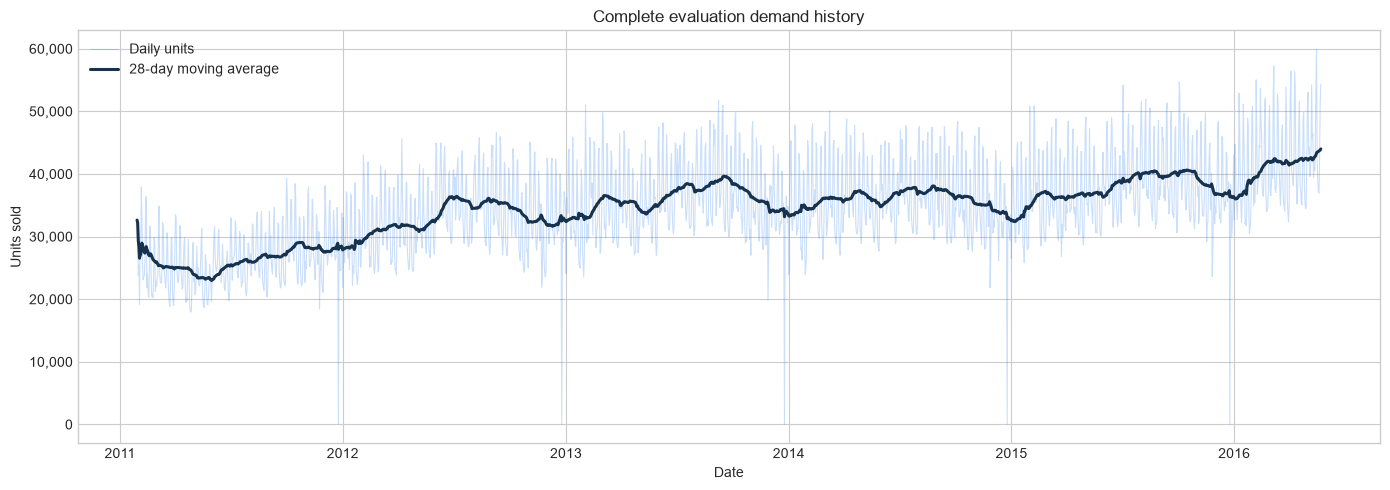

In [43]:
total_units = 0
zero_cells = 0
negative_cells = 0
maximum_daily_units = 0
daily_units = np.zeros(len(evaluation_days), dtype=np.int64)
total_cells = len(sales_evaluation) * len(evaluation_days)

for start in range(0, len(sales_evaluation), 1_000):
    stop = min(start + 1_000, len(sales_evaluation))
    block = sales_evaluation.iloc[start:stop][evaluation_days].to_numpy(dtype=np.int32)
    total_units += int(block.sum())
    zero_cells += int((block == 0).sum())
    negative_cells += int((block < 0).sum())
    maximum_daily_units = max(maximum_daily_units, int(block.max()))
    daily_units += block.sum(axis=0)

sales_profile = pd.DataFrame({
    'value': [
        f'{total_units:,}', f'{zero_cells:,}', f'{zero_cells / total_cells:.2%}',
        f'{negative_cells:,}', f'{maximum_daily_units:,}',
    ]
}, index=['Total units', 'Zero-demand cells', 'Zero-demand share', 'Negative cells', 'Maximum units in one product-store-day'])
display(sales_profile)

daily_sales = calendar.set_index('d').loc[evaluation_days, ['date']].reset_index(drop=True)
daily_sales['units'] = daily_units
daily_sales['moving_average_28'] = daily_sales.units.rolling(28, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_sales.date, daily_sales.units, color=COLORS['blue'], alpha=0.25, linewidth=0.8, label='Daily units')
ax.plot(daily_sales.date, daily_sales.moving_average_28, color=COLORS['navy'], linewidth=2.2, label='28-day moving average')
ax.set(title='Complete evaluation demand history', xlabel='Date', ylabel='Units sold')
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 10. Price profile and sales-price coverage

The price table contains only active product-store weeks. A missing joined price is acceptable when units are zero. A positive sale without a price would understate estimated revenue and must be treated as a quality failure.

,sell_price
count,"$6,841,121.00"
mean,$4.41
std,$3.41
min,$0.01
1%,$0.48
25%,$2.18
50%,$3.47
75%,$5.84
99%,$17.92
max,$107.32


,value
Weekly price records,"6,841,121"
Missing prices inside sell_prices.csv,0
Positive-sales observations,"18,939,271"
Positive sales without joined price,0


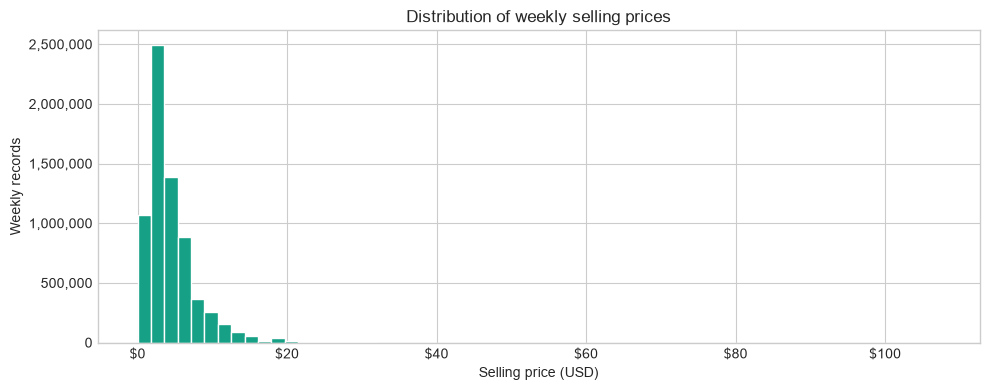

In [44]:
price_profile = prices.sell_price.describe(percentiles=[.01, .25, .50, .75, .99]).to_frame('sell_price')
display(price_profile.style.format({'sell_price': '${:,.2f}'}))

row_index = pd.MultiIndex.from_frame(sales_evaluation[['store_id', 'item_id']])
calendar_days = calendar.set_index('d').loc[evaluation_days].reset_index()
weeks = calendar_days.wm_yr_wk.drop_duplicates().tolist()
price_wide = prices.pivot(index=['store_id', 'item_id'], columns='wm_yr_wk', values='sell_price').reindex(index=row_index, columns=weeks)
week_position = {week: position for position, week in enumerate(weeks)}
day_week_positions = np.array([week_position[week] for week in calendar_days.wm_yr_wk])

positive_sales_without_price = 0
positive_sales_cells = 0
for start in range(0, len(sales_evaluation), 1_000):
    stop = min(start + 1_000, len(sales_evaluation))
    block_units = sales_evaluation.iloc[start:stop][evaluation_days].to_numpy(dtype=np.int32)
    block_prices = price_wide.iloc[start:stop].to_numpy(dtype=np.float32)[:, day_week_positions]
    positive = block_units > 0
    positive_sales_cells += int(positive.sum())
    positive_sales_without_price += int((positive & np.isnan(block_prices)).sum())

coverage = pd.DataFrame({
    'value': [f'{len(prices):,}', f'{prices.sell_price.isna().sum():,}', f'{positive_sales_cells:,}', f'{positive_sales_without_price:,}']
}, index=['Weekly price records', 'Missing prices inside sell_prices.csv', 'Positive-sales observations', 'Positive sales without joined price'])
display(coverage)
assert positive_sales_without_price == 0, 'Revenue cannot be calculated safely: positive sales without price were found.'

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(prices.sell_price, bins=60, color=COLORS['teal'], edgecolor='white')
ax.set(title='Distribution of weekly selling prices', xlabel='Selling price (USD)', ylabel='Weekly records')
ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
fig.tight_layout()
plt.show()

## 11. Missingness visualization

Only columns with at least one missing value are shown. These are calendar event descriptors, where blank means that the date has no corresponding event.

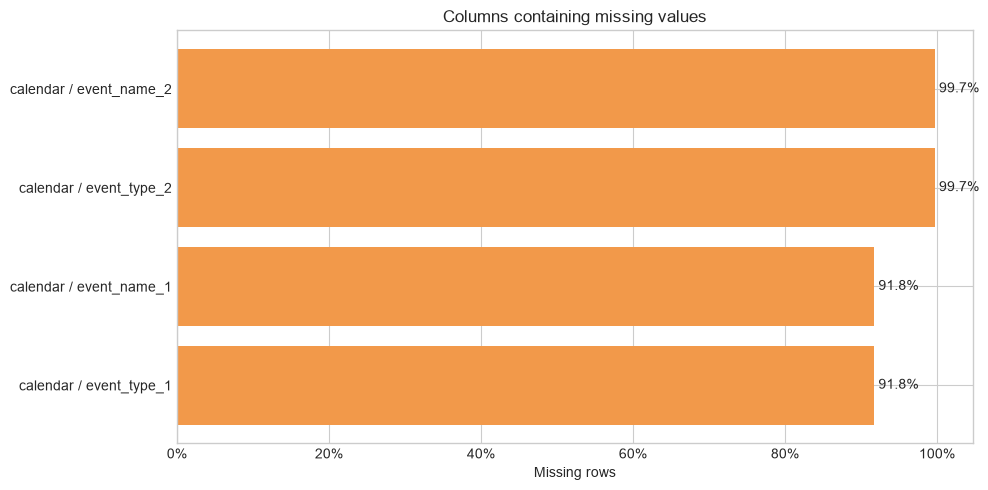

In [45]:
plot_missing = missing_columns.sort_values('missing_percent').copy()
labels = plot_missing.table + ' / ' + plot_missing.column

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(labels, 100 * plot_missing.missing_percent, color=COLORS['orange'])
ax.set(title='Columns containing missing values', xlabel='Missing rows', ylabel='')
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}%'))
for bar, value in zip(bars, plot_missing.missing_percent):
    ax.text(100 * value, bar.get_y() + bar.get_height()/2, f' {value:.1%}', va='center')
fig.tight_layout()
plt.show()

## 12. Final quality decision

The checks distinguish expected blanks from defects that could invalidate a forecast or revenue calculation.

In [46]:
decision = pd.DataFrame([
    ['File completeness', 'PASS', 'All five official files are available.'],
    ['Primary and composite keys', 'PASS', 'No duplicate business keys were found.'],
    ['Sales measurements', 'PASS', 'No missing or negative unit-sales observations were found.'],
    ['Price measurements', 'PASS', 'sell_prices.csv contains no missing prices.'],
    ['Sales-price relationship', 'PASS', 'Every positive sale has a matching weekly price.'],
    ['Calendar missing values', 'EXPECTED', 'Blank event fields mean that no event occurred.'],
    ['Validation/evaluation relationship', 'PASS', 'Evaluation extends validation by exactly 28 observed days.'],
], columns=['area', 'status', 'interpretation'])
display(decision)

,area,status,interpretation
0,File completeness,PASS,All five official files are available.
1,Primary and composite keys,PASS,No duplicate business keys were found.
2,Sales measurements,PASS,No missing or negative unit-sales observations...
3,Price measurements,PASS,sell_prices.csv contains no missing prices.
4,Sales-price relationship,PASS,Every positive sale has a matching weekly price.
5,Calendar missing values,EXPECTED,Blank event fields mean that no event occurred.
6,Validation/evaluation relationship,PASS,Evaluation extends validation by exactly 28 ob...


## Executive conclusion

The M5 source is suitable for demand forecasting. The sales matrices contain no missing or negative measurements, table keys are unique, evaluation extends validation correctly, and every positive sale can be connected to a weekly price. Missing calendar event fields are meaningful blanks rather than data defects. High zero-demand frequency is a real intermittent-demand characteristic and must be considered when selecting metrics and models.